In [1]:
!pip install gspread-dataframe
!pip install shap
!pip install shap lime
!pip install catboost
!pip install streamlit xgboost matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4a8498c7f2a120389c2b8f5157d60d232ac5bd9504e6386aabc11ef46cd589df
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 79.8 MB/s eta 0:00:00


In [2]:
# Importar bibliotecas necessárias
import pandas as pd
from gspread_dataframe import set_with_dataframe
from google.colab import auth
import gspread
from google.auth import default
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn import set_config
# Força o Scikit-Learn a manter os dados como Pandas DataFrame dentro do Pipeline
set_config(transform_output="pandas")
from sklearn.tree import plot_tree
import lime
import lime.lime_tabular
from sklearn.inspection import permutation_importance
from scipy.stats import wilcoxon
import ast
from sklearn.base import clone
from gspread_dataframe import get_as_dataframe
# Importando os 4 Modelos Clássicos
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
# Importando os 4 Modelos Ensemble
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import time
import os
from google.colab import output as colab_output
import joblib

In [3]:
# Para autorizar acesso ao google sheets
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

In [4]:
# link gerado com a tabela
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vR4yYBWPxkOe8IjvjbS3WepA7uhYNNwEcow39UyXztE36W0_ClYYfs0Xhha5-P_oRsrn-rpg-7UyZ9r/pub?gid=344871252&single=true&output=csv'

df = pd.read_csv(url)
df

,Age,Sex,Marital,Income,Race,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,Triglycerides,MetabolicSyndrome
0,22,Male,Single,8200.0,White,81.0,23.3,0,3.88,4.9,92,41,84,0
1,44,Female,Married,4500.0,White,80.1,23.2,0,8.55,4.5,82,28,56,0
2,21,Male,Single,800.0,Asian,69.6,20.1,0,5.07,5.4,107,43,78,0
3,43,Female,Single,2000.0,Black,120.4,33.3,0,5.22,5.0,104,73,141,0
4,51,Male,Married,NaN,Asian,81.1,20.1,0,8.13,5.0,95,43,126,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2396,48,Female,Married,1000.0,Other,NaN,59.7,0,22.11,5.8,152,57,107,0
2397,30,Female,Single,2000.0,Asian,NaN,18.0,0,2.90,7.9,91,90,91,0
2398,28,Male,Single,800.0,MexAmerican,100.8,29.4,0,2.78,6.2,99,47,84,0
2399,27,Male,Married,8200.0,MexAmerican,106.6,31.3,0,4.15,6.2,100,41,124,1


In [5]:
# usar para checar valores de colunas
colunas_analisadas = ['Sex','Marital','Race']
for coluna in colunas_analisadas:
  print(f"--- Valores na coluna '{coluna}' ---")
  display(df[coluna].value_counts(dropna=False))

--- Valores na coluna 'Sex' ---


,count
Sex,
Female,1211
Male,1190


--- Valores na coluna 'Marital' ---


,count
Marital,
Married,1192
Single,498
Divorced,242
NaN,208
Widowed,166
Separated,95


--- Valores na coluna 'Race' ---


,count
Race,
White,933
Black,548
Asian,349
Hispanic,257
MexAmerican,253
Other,61


In [ ]:
# # Mostra o total de valores NaN (nulos) por coluna
# display(df.isnull().sum())

# # Mostra o tipo de dado de cada coluna (se é número int, float ou texto/object)
# df.info()

In [6]:
# 1. TRATAMENTO DE VALORES NULOS (NaN)
df_processada = df
# Categóricos: Preenchendo os 208 vazios de 'Marital' com a moda (categoria mais frequente)
df_processada['Marital'] = df_processada['Marital'].fillna('Married')

# Numéricos: Calculando a mediana de cada coluna e preenchendo os vazios
mediana_income = df_processada['Income'].median()
df_processada['Income'] = df_processada['Income'].fillna(mediana_income)

mediana_waist = df_processada['WaistCirc'].median()
df_processada['WaistCirc'] = df_processada['WaistCirc'].fillna(mediana_waist)

mediana_bmi = df_processada['BMI'].median()
df_processada['BMI'] = df_processada['BMI'].fillna(mediana_bmi)

# usar para checar valores de colunas
colunas_analisadas = ['Sex','Marital','Race']
for coluna in colunas_analisadas:
  print(f"--- Valores na coluna '{coluna}' ---")
  display(df[coluna].value_counts(dropna=False))

--- Valores na coluna 'Sex' ---


,count
Sex,
Female,1211
Male,1190


--- Valores na coluna 'Marital' ---


,count
Marital,
Married,1400
Single,498
Divorced,242
Widowed,166
Separated,95


--- Valores na coluna 'Race' ---


,count
Race,
White,933
Black,548
Asian,349
Hispanic,257
MexAmerican,253
Other,61


In [7]:
# 2. CODIFICAÇÃO DE TEXTO PARA NÚMERO (ENCODING)

# Transformando 'Sex' em 0 (Male) e 1 (Female)
df_processada['Sex'] = df_processada['Sex'].map({'Male': 0, 'Female': 1})

# One-Hot Encoding para 'Marital' e 'Race'
df_processada = pd.get_dummies(df_processada, columns=['Marital', 'Race'], drop_first=True, dtype=int)


# 3. VERIFICAÇÃO FINAL
print("Verificação de valores nulos após a limpeza (tudo deve ser 0):")
display(df_processada.isnull().sum())

print("\nFormato final da base de dados (linhas, colunas):")
print(df_processada.shape)

Verificação de valores nulos após a limpeza (tudo deve ser 0):


,0
Age,0
Sex,0
Income,0
WaistCirc,0
BMI,0
Albuminuria,0
UrAlbCr,0
UricAcid,0
BloodGlucose,0
HDL,0



Formato final da base de dados (linhas, colunas):
(2401, 21)


In [8]:
#fazendo o tratamento das strings e convertendo em float
for coluna in df_processada.columns:
  df_processada[coluna] = df_processada[coluna].astype(float)

# 1. Cria a cópia do dataset processado
df_processada_a_ser_salva = df_processada.copy()

# 2. Puxa a planilha original
planilha = gc.open("Metabolic Syndrome")
aba_dados_originais = planilha.worksheet("Metabolic Syndrome(original)")
df_dados_originais = get_as_dataframe(aba_dados_originais)

# 3. Limpa linhas totalmente vazias que o Sheets costuma trazer
df_dados_originais = df_dados_originais.dropna(how='all')

# VERIFICAÇÃO DE SEGURANÇA: As duas tabelas têm o mesmo tamanho?
if len(df_processada_a_ser_salva) == len(df_dados_originais):
    print("Sucesso: As tabelas têm o mesmo número de linhas!")

    # Pega a coluna seqn e garante que os índices são os mesmos do df processado
    coluna_seqn = df_dados_originais['seqn'].values

    # Insere a coluna na posição 0
    df_processada_a_ser_salva.insert(0, 'seqn', coluna_seqn)

    # Salva o arquivo final
    df_processada_a_ser_salva.to_csv('dataset_app.csv', index=False)
    print("Arquivo 'dataset_app.csv' salvo com a coluna seqn!")
else:
    print(f"ERRO: O df original tem {len(df_dados_originais)} linhas, mas o processado tem {len(df_processada_a_ser_salva)}.")
    print("Você removeu linhas durante o pré-processamento. O cruzamento vai misturar os IDs!")

Sucesso: As tabelas têm o mesmo número de linhas!
Arquivo 'dataset_app.csv' salvo com a coluna seqn!


In [9]:
#vendo a nova tabela após o processamento
df_processada

,Age,Sex,Income,WaistCirc,BMI,Albuminuria,UrAlbCr,UricAcid,BloodGlucose,HDL,...,MetabolicSyndrome,Marital_Married,Marital_Separated,Marital_Single,Marital_Widowed,Race_Black,Race_Hispanic,Race_MexAmerican,Race_Other,Race_White
0,22.0,0.0,8200.0,81.0,23.3,0.0,3.88,4.9,92.0,41.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,44.0,1.0,4500.0,80.1,23.2,0.0,8.55,4.5,82.0,28.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,21.0,0.0,800.0,69.6,20.1,0.0,5.07,5.4,107.0,43.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,43.0,1.0,2000.0,120.4,33.3,0.0,5.22,5.0,104.0,73.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,51.0,0.0,2500.0,81.1,20.1,0.0,8.13,5.0,95.0,43.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2396,48.0,1.0,1000.0,97.0,59.7,0.0,22.11,5.8,152.0,57.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2397,30.0,1.0,2000.0,97.0,18.0,0.0,2.90,7.9,91.0,90.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2398,28.0,0.0,800.0,100.8,29.4,0.0,2.78,6.2,99.0,47.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2399,27.0,0.0,8200.0,106.6,31.3,0.0,4.15,6.2,100.0,41.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [10]:
# Função pra salvar no google sheets
def salvar_no_google_sheets(nome_planilha_destino,nome_do_sheet,df_sendo_salvo):
  #Salvando numa planilha
  planilha_onde_salvar = gc.open(nome_planilha_destino)
  sheets = planilha_onde_salvar.worksheets()
  if nome_do_sheet not in [sheet.title for sheet in sheets]:
    planilha_onde_salvar.add_worksheet(title=nome_do_sheet, rows="1000", cols="200")
  nova_aba_salva = planilha_onde_salvar.worksheet(nome_do_sheet)
  nova_aba_salva.clear()
  # Envie o DataFrame para o Google Sheets
  set_with_dataframe(nova_aba_salva, df_sendo_salvo)

# FUNÇÃO DE EXECUÇÃO DO GRID SEARCH E AVALIAÇÃO
def avaliar_modelos_classificacao_com_grid_search(x_train, x_test, y_train, y_test, modelos, cv_folds=10):
  resultados = []
  melhores_modelos = {} # Vamos guardar os campeões aqui para usar no SHAP depois

  print(f"Iniciando o treinamento e Grid Search com Validação Cruzada de {cv_folds} dobras...\n")

  for nome, config in modelos.items():
      print(f"Treinando {nome}...")

      # Configura o GridSearch
      grid_search = GridSearchCV(
          config["pipeline"],
          config["params"],
          cv=cv_folds,
          scoring='f1',
          n_jobs=-1
      )

      # Roda o treinamento
      grid_search.fit(x_train, y_train)

      # Salva o melhor modelo encontrado
      melhor_modelo = grid_search.best_estimator_
      melhores_modelos[nome] = melhor_modelo

      # Faz predições no conjunto de teste (os 20% separados)
      y_pred = melhor_modelo.predict(x_test)

      # Calcula métricas finais
      acc = accuracy_score(y_test, y_pred)
      prec = precision_score(y_test, y_pred)
      rec = recall_score(y_test, y_pred)
      f1 = f1_score(y_test, y_pred)

      # Guarda os resultados com os melhores parâmetros escolhidos pela máquina
      resultados.append({
          "Modelo": nome,
          "Acurácia": acc,
          "Precisão": prec,
          "Recall": rec,
          "F1-Score": f1,
          "Melhores Parâmetros": str(grid_search.best_params_)
      })
  # Converte para DataFrame
  df_res = pd.DataFrame(resultados).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
  return df_res, melhores_modelos

In [11]:
#salvando no sheets a base após o processamento
salvar_no_google_sheets("Metabolic Syndrome","pos-procesamento",df_processada)

In [12]:
# SEPARAÇÃO DOS DADOS PARA TREINO E TESTE
input = df_processada.drop(columns=['MetabolicSyndrome'])
output = df_processada['MetabolicSyndrome']

# Dividir os dados em 80% para treino e 20% para teste
# O stratify garante que a proporção de doentes/saudáveis fique igual no treino e no teste
x_train, x_test, y_train, y_test = train_test_split(
    input, output, test_size=0.20, random_state=42, shuffle=True, stratify=output
)



*   Não rodar esses se ja tiver feito o gridsearch!



In [ ]:
# DEFINIÇÃO DOS PIPELINES E GRADES DE PARÂMETROS (GRID SEARCH)
# O Pipeline garante que o StandardScaler seja aplicado APÓS a divisão interna do Cross-Validation (evita Data Leakage)

# --- CLÁSSICOS ---
modelos_classicos = {
    "Regressão Logística": {
        "pipeline": Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=2000, random_state=42))]),
        "params": {
            'lr__C': [0.01, 0.1, 1, 10, 100], # Testa um espectro maior de regularização
            'lr__solver': ['lbfgs', 'liblinear'] # Testa diferentes algoritmos de otimização
        }
    },
    "KNN": {
        "pipeline": Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
        "params": {
            'knn__n_neighbors': [3, 5, 7, 9, 11, 15], # Mais opções de vizinhos
            'knn__weights': ['uniform', 'distance'], # Testa se vizinhos próximos pesam mais
            'knn__metric': ['euclidean', 'manhattan'] # Diferentes formas de calcular distância
        }
    },
    "SVM": {
        "pipeline": Pipeline([('scaler', StandardScaler()), ('svm', SVC(probability=True, random_state=42))]),
        "params": {
            'svm__C': [0.1, 1, 10, 50],
            'svm__kernel': ['linear', 'rbf'],
            'svm__gamma': ['scale', 'auto', 0.1, 0.01] # Afeta a curvatura da fronteira de decisão
        }
    },
    "Árvore de Decisão": {
        "pipeline": Pipeline([('scaler', StandardScaler()), ('dt', DecisionTreeClassifier(random_state=42))]),
        "params": {
            'dt__max_depth': [None, 5, 10, 15, 20],
            'dt__min_samples_split': [2, 5, 10], # Mínimo de amostras para dividir um nó
            'dt__min_samples_leaf': [1, 2, 4] # Mínimo de amostras que uma folha final deve ter
        }
    },
}

# --- ENSEMBLES ---
modelos_ensembles = {
    "Random Forest": {
        "pipeline": Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=42))]),
        "params": {
            'rf__n_estimators': [50, 100, 200],
            'rf__max_depth': [None, 10, 20],
            'rf__min_samples_split': [2, 5, 10]
        }
    },
    "CatBoost": {
        "pipeline": Pipeline([('scaler', StandardScaler()), ('cat', CatBoostClassifier(random_state=42, verbose=0))]),
        "params": {
            'cat__iterations': [50, 100, 200], # Equivalente ao n_estimators (quantidade de árvores)
            'cat__depth': [4, 6, 8],           # Profundidade da árvore
            'cat__learning_rate': [0.01, 0.05, 0.1] # Passos de aprendizado
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([('scaler', StandardScaler()), ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))]),
        "params": {
            'xgb__n_estimators': [50, 100, 200],
            'xgb__max_depth': [3, 5, 7],
            'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'xgb__subsample': [0.8, 1.0]
        }
    },
    "LightGBM": {
        "pipeline": Pipeline([('scaler', StandardScaler()), ('lgbm', LGBMClassifier(random_state=42, verbose=-1))]),
        "params": {
            'lgbm__n_estimators': [50, 100, 200],
            'lgbm__max_depth': [3, 5, 7],
            'lgbm__learning_rate': [0.01, 0.05, 0.1, 0.2],
            'lgbm__num_leaves': [31, 50]
        }
    }
}

In [ ]:
#PARA OS MODELOS CLÁSSICOS
print("\n=== RESULTADO FINAL DOS MODELOS CLÁSSICOS ===")
df_resultados_classicos, melhores_modelos_classicos = avaliar_modelos_classificacao_com_grid_search(x_train, x_test, y_train, y_test, modelos_classicos)
salvar_no_google_sheets("Metabolic Syndrome","resultados modelos clássicos",df_resultados_classicos)
df_resultados_classicos


=== RESULTADO FINAL DOS MODELOS CLÁSSICOS ===
Iniciando o treinamento e Grid Search com Validação Cruzada de 10 dobras...

Treinando Regressão Logística...
Treinando KNN...
Treinando SVM...
Treinando Árvore de Decisão...


,Modelo,Acurácia,Precisão,Recall,F1-Score,Melhores Parâmetros
0,Árvore de Decisão,0.862786,0.811321,0.781818,0.796296,"{'dt__max_depth': 10, 'dt__min_samples_leaf': ..."
1,Regressão Logística,0.846154,0.809524,0.721212,0.762821,"{'lr__C': 10, 'lr__solver': 'lbfgs'}"
2,SVM,0.841996,0.798658,0.721212,0.757962,"{'svm__C': 50, 'svm__gamma': 0.01, 'svm__kerne..."
3,KNN,0.802495,0.796610,0.569697,0.664311,"{'knn__metric': 'manhattan', 'knn__n_neighbors..."


In [ ]:
#PARA OS MODELOS ENSEMBLE
print("\n=== RESULTADO FINAL DOS MODELOS ENSEMBLE ===")
df_resultados_ensemble, melhores_modelos_ensemble = avaliar_modelos_classificacao_com_grid_search(x_train, x_test, y_train, y_test, modelos_ensembles)
salvar_no_google_sheets("Metabolic Syndrome","resultados modelos ensemble",df_resultados_ensemble)
df_resultados_ensemble


=== RESULTADO FINAL DOS MODELOS ENSEMBLE ===
Iniciando o treinamento e Grid Search com Validação Cruzada de 10 dobras...

Treinando Random Forest...
Treinando CatBoost...
Treinando XGBoost...
Treinando LightGBM...


,Modelo,Acurácia,Precisão,Recall,F1-Score,Melhores Parâmetros
0,CatBoost,0.906445,0.870370,0.854545,0.862385,"{'cat__depth': 4, 'cat__iterations': 200, 'cat..."
1,LightGBM,0.893971,0.843373,0.848485,0.845921,"{'lgbm__learning_rate': 0.1, 'lgbm__max_depth'..."
2,XGBoost,0.891892,0.855346,0.824242,0.839506,"{'xgb__learning_rate': 0.2, 'xgb__max_depth': ..."
3,Random Forest,0.887734,0.849057,0.818182,0.833333,"{'rf__max_depth': None, 'rf__min_samples_split..."




*   Para não ter que rodar o grid search toda vez vamos fazer de um jeito mais
rapido, carregando os melhores valores encontrados.



In [13]:
# 1. Defina os TEMPLATES dos pipelines exatamente como no seu código original
# (As chaves e os nomes dos passos como 'cat', 'lgbm', 'dt' devem ser idênticos)
templates_pipelines_classicos = {
    "Regressão Logística": Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=2000, random_state=42))]),
    "KNN": Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
    "SVM": Pipeline([('scaler', StandardScaler()), ('svm', SVC(probability=True, random_state=42))]),
    "Árvore de Decisão": Pipeline([('scaler', StandardScaler()), ('dt', DecisionTreeClassifier(random_state=42))])
}
templates_pipelines_ensemble = {
    "Random Forest": Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(random_state=42))]),
    "CatBoost": Pipeline([('scaler', StandardScaler()), ('cat', CatBoostClassifier(random_state=42, verbose=0))]),
    "XGBoost": Pipeline([('scaler', StandardScaler()), ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))]),
    "LightGBM": Pipeline([('scaler', StandardScaler()), ('lgbm', LGBMClassifier(random_state=42, verbose=-1))])
}

# 2. Função mágica que lê o DataFrame de resultados, acha os melhores e instancia os modelos
def extrair_e_configurar_melhores_modelos(df_resultados, templates, top_n=2):
    # Garante que os dados estão ordenados pelo F1-Score (do maior para o menor)
    df_ordenado = df_resultados.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

    modelos_prontos = {}

    print(f"--- Configurando os {top_n} melhores modelos baseados no F1-Score ---")
    for i in range(min(top_n, len(df_ordenado))):
        nome_modelo = df_ordenado.loc[i, "Modelo"]
        f1_score_modelo = df_ordenado.loc[i, "F1-Score"]
        str_parametros = df_ordenado.loc[i, "Melhores Parâmetros"]

        # ast.literal_eval converte com segurança a String "{'cat__depth': 4...}" em um Dict real
        dict_parametros = ast.literal_eval(str_parametros)

        if nome_modelo in templates:
            # Clona o template para criar uma instância limpa
            pipeline_configurado = clone(templates[nome_modelo])

            # O set_params desempacota o dicionário e configura os parâmetros do pipeline automaticamente
            pipeline_configurado.set_params(**dict_parametros)

            # Salva no dicionário final
            modelos_prontos[nome_modelo] = pipeline_configurado
            print(f"Top {i+1}: {nome_modelo} (F1: {f1_score_modelo:.4f}) -> Pronto para treino!")
        else:
            print(f"⚠️ Alerta: Template para o modelo '{nome_modelo}' não foi encontrado mapeado.")

    return modelos_prontos

In [14]:
# Supondo que você já tenha o seu objeto 'gc' do gspread autenticado:
planilha = gc.open("Metabolic Syndrome")

# 1. Puxa os dados das duas abas
aba_classicos = planilha.worksheet("resultados modelos clássicos")
aba_ensembles = planilha.worksheet("resultados modelos ensemble")

df_classicos = get_as_dataframe(aba_classicos).dropna(how='all')
df_ensembles = get_as_dataframe(aba_ensembles).dropna(how='all')

# 3. Executa a função para obter os modelos configurados
melhores_modelos_classicos = extrair_e_configurar_melhores_modelos(df_classicos, templates_pipelines_classicos, top_n=2)
melhores_modelos_classicos

--- Configurando os 2 melhores modelos baseados no F1-Score ---
Top 1: Árvore de Decisão (F1: 0.7963) -> Pronto para treino!
Top 2: Regressão Logística (F1: 0.7628) -> Pronto para treino!


{'Árvore de Decisão': Pipeline(steps=[('scaler', StandardScaler()),
                 ('dt',
                  DecisionTreeClassifier(max_depth=10, min_samples_leaf=4,
                                         min_samples_split=10,
                                         random_state=42))]),
 'Regressão Logística': Pipeline(steps=[('scaler', StandardScaler()),
                 ('lr',
                  LogisticRegression(C=10, max_iter=2000, random_state=42))])}

In [15]:
melhores_modelos_ensemble = extrair_e_configurar_melhores_modelos(df_ensembles, templates_pipelines_ensemble, top_n=2)
melhores_modelos_ensemble

--- Configurando os 2 melhores modelos baseados no F1-Score ---
Top 1: CatBoost (F1: 0.8624) -> Pronto para treino!
Top 2: LightGBM (F1: 0.8459) -> Pronto para treino!


{'CatBoost': Pipeline(steps=[('scaler', StandardScaler()),
                 ('cat',
                  CatBoostClassifier(depth=4, iterations=200, learning_rate=0.05, random_state=42, verbose=0))]),
 'LightGBM': Pipeline(steps=[('scaler', StandardScaler()),
                 ('lgbm',
                  LGBMClassifier(max_depth=5, random_state=42, verbose=-1))])}

In [16]:
def treinar_e_avaliar_modelos_finais(x_train, x_test, y_train, y_test, lista_dicionarios_modelos):
    resultados_finais = []

    # Unifica os dicionários (clássicos e ensembles) em um só lugar para facilitar o loop
    modelos_para_treinar = {}
    for dicionario in lista_dicionarios_modelos:
        modelos_para_treinar.update(dicionario)

    print("--- Iniciando o Treinamento Final ---")

    for nome_modelo, pipeline in modelos_para_treinar.items():
        print(f"Ajustando {nome_modelo} aos dados de treino...")

        # 1. Treina o modelo (rápido, pois não há mais GridSearch)
        pipeline.fit(x_train, y_train)

        # 2. Faz as predições usando os 20% de dados separados para teste
        y_pred = pipeline.predict(x_test)

        # 3. Identifica a categoria para ficar bonito no relatório final
        categoria = "Clássico" if nome_modelo in templates_pipelines_classicos else "Ensemble"

        # 4. Calcula e armazena as métricas
        resultados_finais.append({
            "Categoria": categoria,
            "Modelo": nome_modelo,
            "Acurácia": accuracy_score(y_test, y_pred),
            "Precisão": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-Score": f1_score(y_test, y_pred)
        })

    # Converte os resultados para um DataFrame, ordenando pelo F1-Score geral
    df_resultados_finais = pd.DataFrame(resultados_finais).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

    print("\nAvaliação concluída com sucesso!")
    return df_resultados_finais

# --- EXECUÇÃO ---

# Passamos os dois dicionários que você gerou na etapa anterior em formato de lista
df_avaliacao_final = treinar_e_avaliar_modelos_finais(
    x_train, x_test, y_train, y_test,
    [melhores_modelos_classicos, melhores_modelos_ensemble]
)

# Visualizar a tabela final
display(df_avaliacao_final)

--- Iniciando o Treinamento Final ---
Ajustando Árvore de Decisão aos dados de treino...
Ajustando Regressão Logística aos dados de treino...
Ajustando CatBoost aos dados de treino...
Ajustando LightGBM aos dados de treino...

Avaliação concluída com sucesso!


,Categoria,Modelo,Acurácia,Precisão,Recall,F1-Score
0,Ensemble,CatBoost,0.906445,0.870370,0.854545,0.862385
1,Ensemble,LightGBM,0.893971,0.843373,0.848485,0.845921
2,Clássico,Árvore de Decisão,0.862786,0.811321,0.781818,0.796296
3,Clássico,Regressão Logística,0.846154,0.809524,0.721212,0.762821


In [17]:
print("--- Iniciando o treinamento final dos modelos ---")

# Laço simples para treinar cada pipeline com os dados de treino
for nome, pipeline in melhores_modelos_classicos.items():
    print(f"Treinando {nome}...")
    pipeline.fit(x_train, y_train)
for nome, pipeline in melhores_modelos_ensemble.items():
    print(f"Treinando {nome}...")
    pipeline.fit(x_train, y_train)

print("\nTreinamento concluído! Os modelos estão prontos.")

--- Iniciando o treinamento final dos modelos ---
Treinando Árvore de Decisão...
Treinando Regressão Logística...
Treinando CatBoost...
Treinando LightGBM...

Treinamento concluído! Os modelos estão prontos.


In [18]:
# Salvando para usar no app.py
# 1. Pegamos os pipelines vencedores
pipeline_classico = melhores_modelos_classicos["Árvore de Decisão"]
pipeline_ensemble = melhores_modelos_ensemble["CatBoost"]

# 2. Desacoplamos e salvamos o Escalonador, o CatBoost e a Árvore de Decisão
joblib.dump(pipeline_classico.named_steps['scaler'], 'scaler.pkl')
joblib.dump(pipeline_classico.named_steps['dt'], 'modelo_dt.pkl')
joblib.dump(pipeline_ensemble.named_steps['cat'], 'modelo_cat.pkl')

print("✅ Modelos otimizados pelo GridSearch exportados com sucesso para o Streamlit!")

✅ Modelos otimizados pelo GridSearch exportados com sucesso para o Streamlit!


### Teste de Wilcoxon (Wilcoxon Signed-Rank Test)

- Como foi usada a Validação Cruzada com 10 dobras (cv=10), cada modelo gerou 10 notas de F1-Score diferentes (uma para cada dobra). O teste estatístico vai colocar as 10 notas do Campeão contra as 10 notas do Vice-Campeão e verificar se o campeão ganhou a maioria das vezes de forma consistente.

- O teste mais recomendado na literatura de Machine Learning para comparar modelos é o Teste de Wilcoxon (Wilcoxon Signed-Rank Test), porque ele não exige que os dados sigam uma distribuição normal perfeita.

In [19]:
# 1. ISOLAR OS CAMPEÕES E OS VICES
# Ensembles
modelo_catboost = melhores_modelos_ensemble["CatBoost"]
modelo_lightgbm = melhores_modelos_ensemble["LightGBM"]

# Clássicos
modelo_arvore = melhores_modelos_classicos["Árvore de Decisão"]
modelo_lr = melhores_modelos_classicos["Regressão Logística"]

print("Extraindo as 10 notas (F1-Score) de cada modelo nas dobras de validação...")

# 2. CALCULAR AS NOTAS DAS 10 DOBRAS PARA CADA MODELO
# Usamos n_jobs=-1 para ir mais rápido
notas_catboost = cross_val_score(modelo_catboost, x_train, y_train, cv=10, scoring='f1', n_jobs=-1)
notas_lightgbm = cross_val_score(modelo_lightgbm, x_train, y_train, cv=10, scoring='f1', n_jobs=-1)

notas_arvore = cross_val_score(modelo_arvore, x_train, y_train, cv=10, scoring='f1', n_jobs=-1)
notas_lr = cross_val_score(modelo_lr, x_train, y_train, cv=10, scoring='f1', n_jobs=-1)

# 3. APLICAR O TESTE ESTATÍSTICO (WILCOXON)
print("\n==================================================")
print(" RESULTADOS DO TESTE ESTATÍSTICO DE WILCOXON")
print("==================================================\n")

# Teste para os Ensembles
_, p_value_ensemble = wilcoxon(notas_catboost, notas_lightgbm)
print("--- BATALHA DOS ENSEMBLES: CatBoost vs LightGBM ---")
print(f"Média CatBoost: {np.mean(notas_catboost):.4f} | Média LightGBM: {np.mean(notas_lightgbm):.4f}")
print(f"Valor-p (p-value): {p_value_ensemble:.5f}")

if p_value_ensemble < 0.05:
    print("✅ CONCLUSÃO: O CatBoost é ESTATISTICAMENTE SUPERIOR ao LightGBM.")
else:
    print("⚠️ CONCLUSÃO: Empate Técnico. A diferença não é estatisticamente significativa.")

print("\n--------------------------------------------------\n")

# Teste para os Clássicos
_, p_value_classicos = wilcoxon(notas_arvore, notas_lr)
print("--- BATALHA DOS CLÁSSICOS: Árvore de Decisão vs Regressão Logística ---")
print(f"Média Árvore: {np.mean(notas_arvore):.4f} | Média Reg. Logística: {np.mean(notas_lr):.4f}")
print(f"Valor-p (p-value): {p_value_classicos:.5f}")

if p_value_classicos < 0.05:
    print("✅ CONCLUSÃO: A Árvore de Decisão é ESTATISTICAMENTE SUPERIOR à Regressão Logística.")
else:
    print("⚠️ CONCLUSÃO: Empate Técnico. A diferença não é estatisticamente significativa.")

Extraindo as 10 notas (F1-Score) de cada modelo nas dobras de validação...

 RESULTADOS DO TESTE ESTATÍSTICO DE WILCOXON

--- BATALHA DOS ENSEMBLES: CatBoost vs LightGBM ---
Média CatBoost: 0.8406 | Média LightGBM: 0.8367
Valor-p (p-value): 0.62500
⚠️ CONCLUSÃO: Empate Técnico. A diferença não é estatisticamente significativa.

--------------------------------------------------

--- BATALHA DOS CLÁSSICOS: Árvore de Decisão vs Regressão Logística ---
Média Árvore: 0.7914 | Média Reg. Logística: 0.7500
Valor-p (p-value): 0.00977
✅ CONCLUSÃO: A Árvore de Decisão é ESTATISTICAMENTE SUPERIOR à Regressão Logística.


**Como ler os resultados para colocar no texto do TCC**:

O número mágico na ciência é o 0.05 (nível de significância de 5%).

- Se o p-value for MENOR que 0.05: Você tem uma vitória com comprovação científica. Pode escrever na monografia: "O teste de Wilcoxon confirmou, com 95% de confiança (p < 0.05), que o CatBoost possui desempenho superior aos demais."

- Se o p-value for MAIOR que 0.05: Deu empate técnico! Isso também é um resultado científico válido. Você escreve: "Apesar do CatBoost apresentar um F1-Score levemente maior, o teste estatístico (p > 0.05) indicou um empate técnico com o LightGBM, demonstrando que ambos os modelos lidam igualmente bem com a detecção da síndrome."

In [20]:
# TESTE DE FORMA DETALHADA
# 1. CRIANDO A TABELA DETALHADA DOS ENSEMBLES
# Usando as notas_catboost e notas_lightgbm já calculadas na validação cruzada
df_ensembles = pd.DataFrame({
    'Dobra (Fold)': [f'Fold {i+1}' for i in range(10)],
    'F1-Score (CatBoost)': notas_catboost,
    'F1-Score (LightGBM)': notas_lightgbm
})

# Calculando a diferença passo a passo
df_ensembles['Diferença (Cat - LGBM)'] = df_ensembles['F1-Score (CatBoost)'] - df_ensembles['F1-Score (LightGBM)']

# Rodando o teste de Wilcoxon
stat_ens, p_value_ens = wilcoxon(df_ensembles['F1-Score (CatBoost)'], df_ensembles['F1-Score (LightGBM)'])

# Criando a linha de consolidação final com as médias e o p-valor obtido
linha_resumo_ens = pd.DataFrame({
    'Dobra (Fold)': ['MÉDIA / RESULTADO'],
    'F1-Score (CatBoost)': [df_ensembles['F1-Score (CatBoost)'].mean()],
    'F1-Score (LightGBM)': [df_ensembles['F1-Score (LightGBM)'].mean()],
    'Diferença (Cat - LGBM)': [f'p-value: {p_value_ens:.5f}']
})
df_ensembles_final = pd.concat([df_ensembles, linha_resumo_ens], ignore_index=True)


# 2. CRIANDO A TABELA DETALHADA DOS CLÁSSICOS
# Usando as notas_arvore e notas_lr já calculadas na validação cruzada
df_classicos = pd.DataFrame({
    'Dobra (Fold)': [f'Fold {i+1}' for i in range(10)],
    'F1-Score (Árvore)': notas_arvore,
    'F1-Score (Reg. Logística)': notas_lr
})

# Calculando a diferença passo a passo
df_classicos['Diferença (Árvore - LR)'] = df_classicos['F1-Score (Árvore)'] - df_classicos['F1-Score (Reg. Logística)']

# Rodando o teste de Wilcoxon
stat_clas, p_value_clas = wilcoxon(df_classicos['F1-Score (Árvore)'], df_classicos['F1-Score (Reg. Logística)'])

# Criando a linha de consolidação final com as médias e o p-valor obtido
linha_resumo_clas = pd.DataFrame({
    'Dobra (Fold)': ['MÉDIA / RESULTADO'],
    'F1-Score (Árvore)': [df_classicos['F1-Score (Árvore)'].mean()],
    'F1-Score (Reg. Logística)': [df_classicos['F1-Score (Reg. Logística)'].mean()],
    'Diferença (Árvore - LR)': [f'p-value: {p_value_clas:.5f}']
})
df_classicos_final = pd.concat([df_classicos, linha_resumo_clas], ignore_index=True)


# 3. EXIBIÇÃO DOS RESULTADOS NO NOTEBOOK
print("=== DETALHAMENTO DO TESTE ESTATÍSTICO (ENSEMBLES) ===")
display(df_ensembles_final)

print("\n=== DETALHAMENTO DO TESTE ESTATÍSTICO (CLÁSSICOS) ===")
display(df_classicos_final)


# 4. SALVAMENTO AUTOMÁTICO NO GOOGLE SHEETS
print("\nIniciando exportação para o Google Sheets...")

# Enviando a tabela de Ensembles para a aba dedicada
salvar_no_google_sheets(
    nome_planilha_destino="Metabolic Syndrome",
    nome_do_sheet="detalhes_wilcoxon_ensembles",
    df_sendo_salvo=df_ensembles_final
)

# Enviando a tabela de Clássicos para a aba dedicada
salvar_no_google_sheets(
    nome_planilha_destino="Metabolic Syndrome",
    nome_do_sheet="detalhes_wilcoxon_classicos",
    df_sendo_salvo=df_classicos_final
)

=== DETALHAMENTO DO TESTE ESTATÍSTICO (ENSEMBLES) ===


,Dobra (Fold),F1-Score (CatBoost),F1-Score (LightGBM),Diferença (Cat - LGBM)
0,Fold 1,0.859375,0.837209,0.022166
1,Fold 2,0.818182,0.846154,-0.027972
2,Fold 3,0.870968,0.861538,0.009429
3,Fold 4,0.839695,0.874074,-0.034379
4,Fold 5,0.818182,0.829630,-0.011448
5,Fold 6,0.880000,0.848000,0.032
6,Fold 7,0.818898,0.796875,0.022023
7,Fold 8,0.837209,0.828125,0.009084
8,Fold 9,0.885496,0.883721,0.001775
9,Fold 10,0.777778,0.761905,0.015873



=== DETALHAMENTO DO TESTE ESTATÍSTICO (CLÁSSICOS) ===


,Dobra (Fold),F1-Score (Árvore),F1-Score (Reg. Logística),Diferença (Árvore - LR)
0,Fold 1,0.784000,0.781250,0.00275
1,Fold 2,0.816901,0.775862,0.041039
2,Fold 3,0.775194,0.727273,0.047921
3,Fold 4,0.806452,0.738462,0.06799
4,Fold 5,0.764706,0.778626,-0.01392
5,Fold 6,0.852713,0.760331,0.092383
6,Fold 7,0.814815,0.735043,0.079772
7,Fold 8,0.750000,0.714286,0.035714
8,Fold 9,0.803150,0.800000,0.00315
9,Fold 10,0.746032,0.689076,0.056956



Iniciando exportação para o Google Sheets...


## REALIZANDO O XAI


### modelos clássicos

--- INICIANDO LABORATÓRIO DE XAI (ÁRVORE DE DECISÃO) ---

1. Calculando Permutação (Global)...


,Variável,Importância Média (Queda no F1),Desvio Padrão
8,BloodGlucose,0.144563,0.012528
10,Triglycerides,0.118635,0.015216
3,WaistCirc,0.088867,0.026136
1,Sex,0.067394,0.004910
9,HDL,0.063269,0.009656



2. Calculando SHAP Values...

> Gráfico SHAP Global (Summary Plot) - Árvore de Decisão:


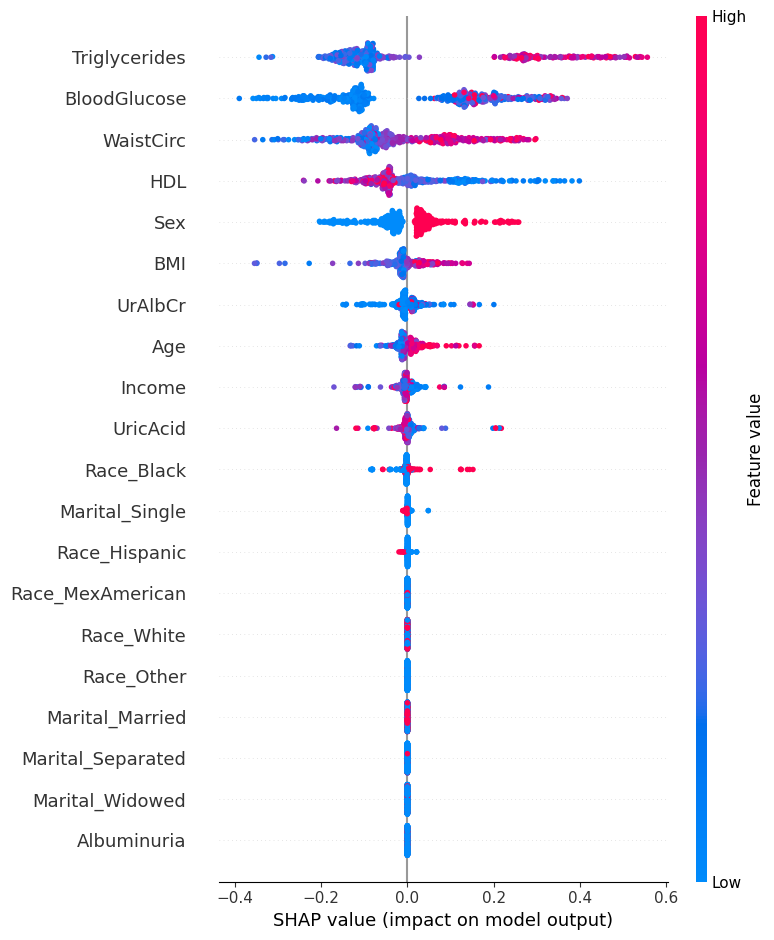


> Gráfico SHAP Local (Waterfall) para o Paciente 0 - Árvore de Decisão:
Diagnóstico Real: 0.0 | O Modelo disse: 0.0


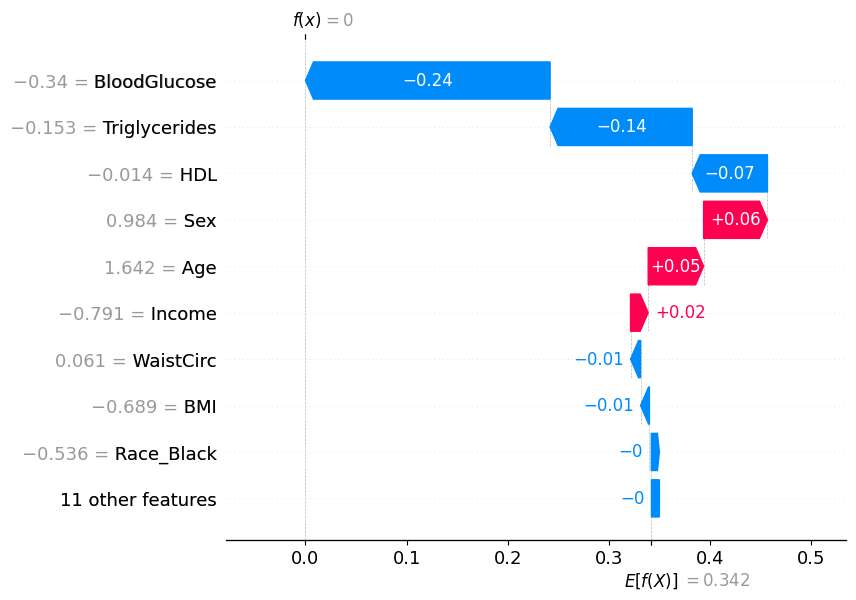


3. Calculando LIME (Local)...

> Explicação LIME para o Paciente 0 - Árvore de Decisão:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [21]:
# 1. ISOLANDO O MODELO CAMPEÃO DOS CLÁSSICOS E OS DADOS
# Pegamos o Pipeline vencedor do dicionário de clássicos
pipeline_classico = melhores_modelos_classicos["Árvore de Decisão"]

# Desacoplamos o escalonador e o modelo de árvore
scaler_classico = pipeline_classico.named_steps['scaler']
modelo_dt = pipeline_classico.named_steps['dt']

# Aplicamos a escala aos dados
X_train_scaled_classico = scaler_classico.transform(x_train)
X_test_scaled_classico = scaler_classico.transform(x_test)

print("--- INICIANDO LABORATÓRIO DE XAI (ÁRVORE DE DECISÃO) ---\n")

# ==========================================
# TÉCNICA 1: PERMUTATION FEATURE IMPORTANCE (GLOBAL)
# ==========================================
print("1. Calculando Permutação (Global)...")
resultado_permutacao_dt = permutation_importance(
    modelo_dt, X_test_scaled_classico, y_test, scoring='f1', n_repeats=5, random_state=42
)

df_permutacao_dt = pd.DataFrame({
    'Variável': X_test_scaled_classico.columns,
    'Importância Média (Queda no F1)': resultado_permutacao_dt.importances_mean,
    'Desvio Padrão': resultado_permutacao_dt.importances_std
}).sort_values(by='Importância Média (Queda no F1)', ascending=False)

display(df_permutacao_dt.head(5))

# ==========================================
# TÉCNICA 2: SHAP (GLOBAL E LOCAL)
# ==========================================
print("\n2. Calculando SHAP Values...")
explainer_shap_dt = shap.TreeExplainer(modelo_dt)
shap_values_dt = explainer_shap_dt(X_test_scaled_classico)

print("\n> Gráfico SHAP Global (Summary Plot) - Árvore de Decisão:")
plt.figure()
# CORREÇÃO: Avisamos ao Summary Plot para olhar apenas para a Classe 1 (Doente)
shap.summary_plot(shap_values_dt[:, :, 1], X_test_scaled_classico)
plt.show()

# Escolhendo o Paciente 0
id_paciente = 0
diagnostico_real_dt = y_test.iloc[id_paciente]
predicao_modelo_dt = modelo_dt.predict(X_test_scaled_classico.iloc[[id_paciente]])[0]

print(f"\n> Gráfico SHAP Local (Waterfall) para o Paciente {id_paciente} - Árvore de Decisão:")
print(f"Diagnóstico Real: {diagnostico_real_dt} | O Modelo disse: {predicao_modelo_dt}")
plt.figure()
# CORREÇÃO: Avisamos ao Waterfall para olhar para o paciente selecionado, todas as variáveis (:), e focar na Classe 1
shap.plots.waterfall(shap_values_dt[id_paciente, :, 1])
plt.show()

# ==========================================
# TÉCNICA 3: LIME (LOCAL)
# ==========================================
print("\n3. Calculando LIME (Local)...")
explainer_lime_dt = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled_classico.values,
    feature_names=X_train_scaled_classico.columns.tolist(),
    class_names=['Saudável (0)', 'Doente (1)'],
    mode='classification',
    random_state=42
)

exp_lime_dt = explainer_lime_dt.explain_instance(
    data_row=X_test_scaled_classico.values[id_paciente],
    predict_fn=modelo_dt.predict_proba,
    num_features=10
)

print(f"\n> Explicação LIME para o Paciente {id_paciente} - Árvore de Decisão:")
exp_lime_dt.show_in_notebook(show_table=True)


> Plotando a Árvore de Decisão Original (Caixa-Branca):


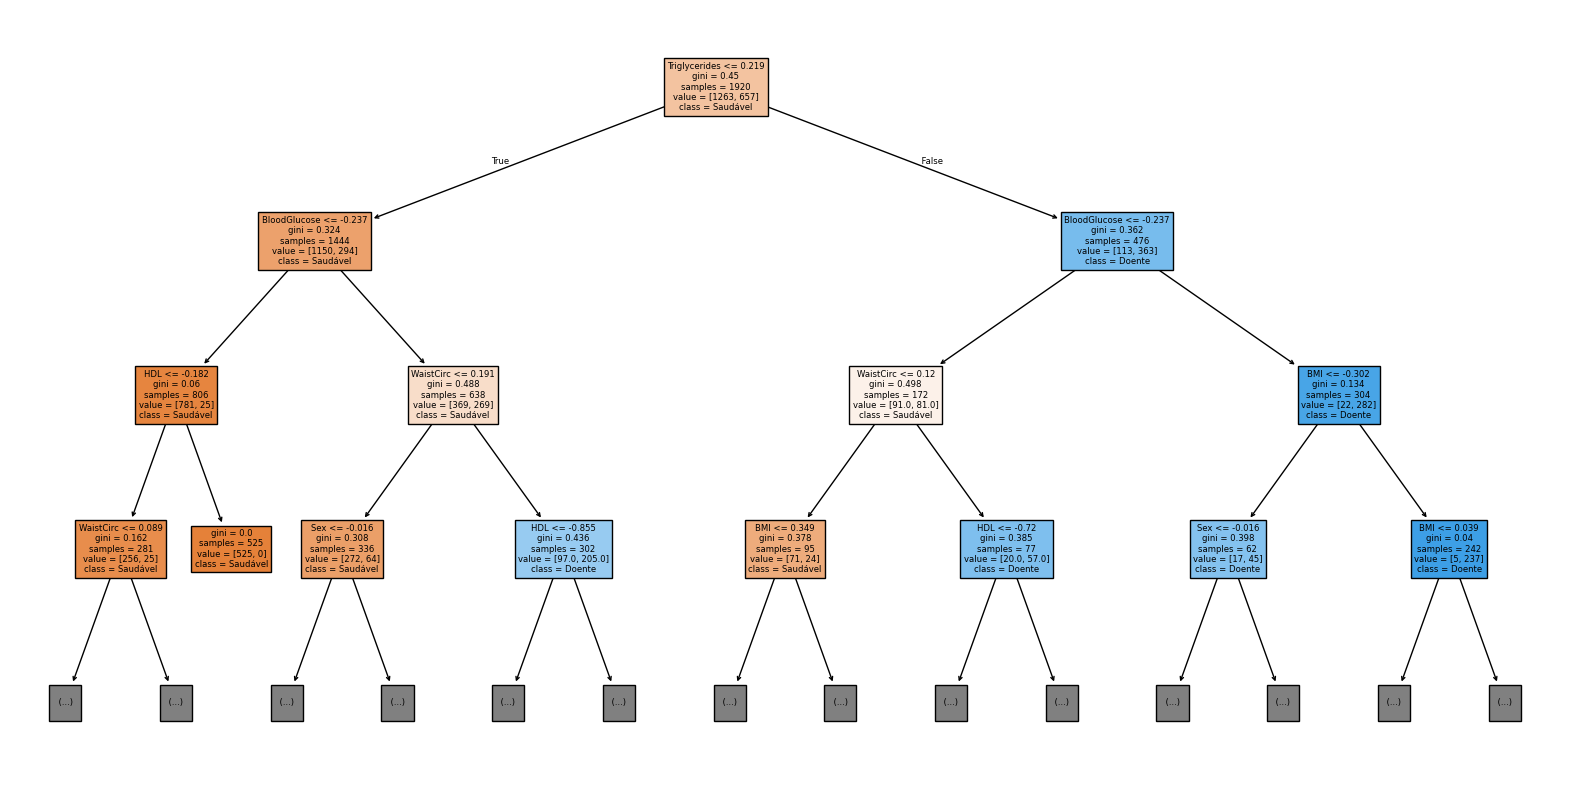

In [ ]:
print("\n> Plotando a Árvore de Decisão Original (Caixa-Branca):")
plt.figure(figsize=(20,10))
plot_tree(modelo_dt, feature_names=X_test_scaled_classico.columns, class_names=['Saudável', 'Doente'], filled=True, max_depth=3)
plt.show()

### modelos ensemble

--- INICIANDO LABORATÓRIO DE XAI (CATBOOST - ENSEMBLE) ---

1. Calculando Permutação (Global)...


,Variável,Importância Média (Queda no F1),Desvio Padrão
8,BloodGlucose,0.146464,0.009263
10,Triglycerides,0.122920,0.017962
3,WaistCirc,0.114740,0.018569
9,HDL,0.073357,0.012088
1,Sex,0.058115,0.016687



2. Calculando SHAP Values...

> Gráfico SHAP Global (Summary Plot) - CatBoost:


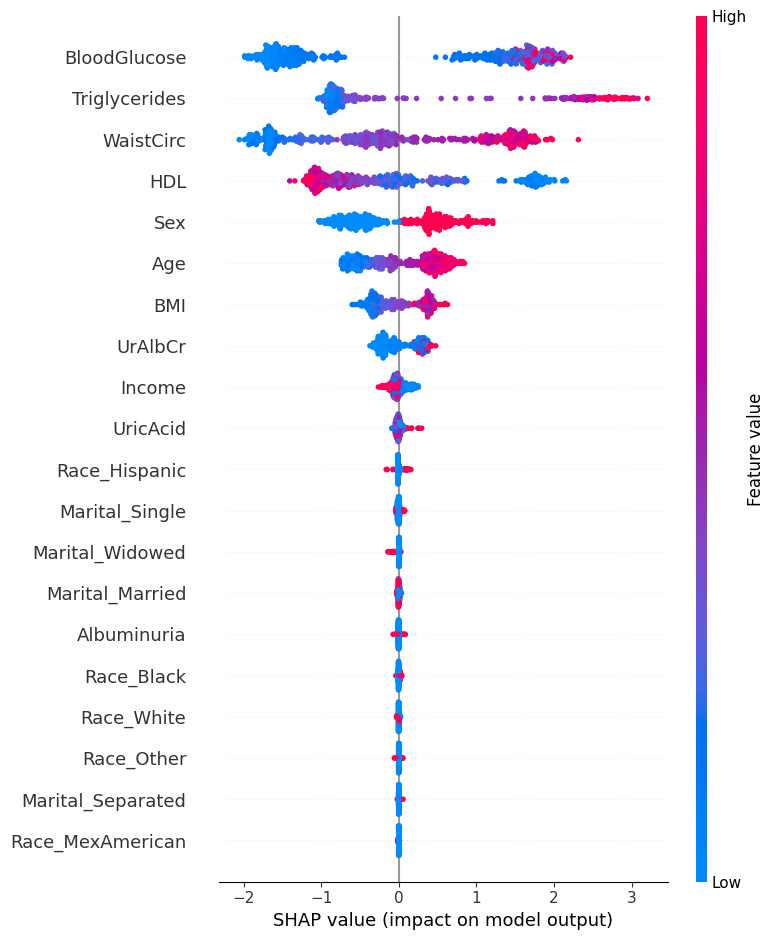


> Gráfico SHAP Local (Waterfall) para o Paciente 0 - CatBoost:
Diagnóstico Real: 0.0 | O Modelo disse: 0.0


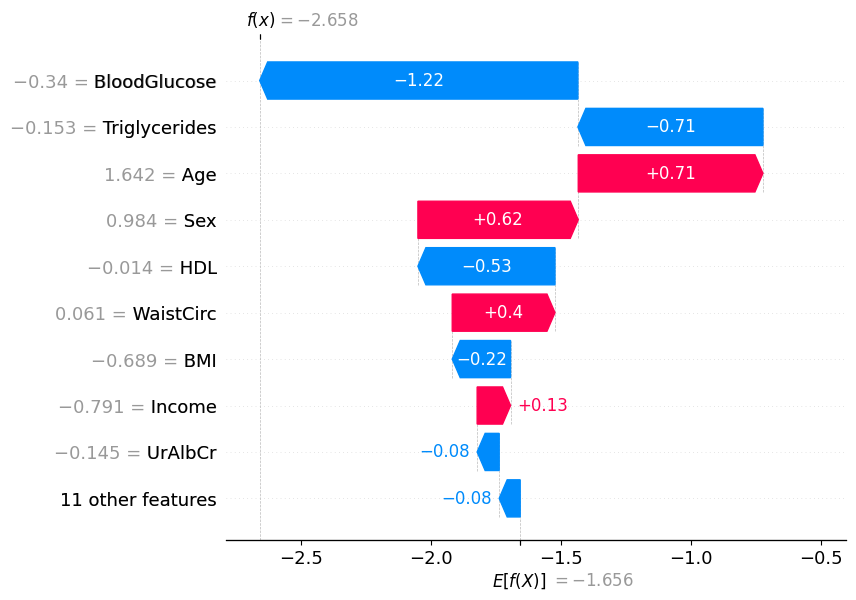


3. Calculando LIME (Local)...

> Explicação LIME para o Paciente 0 - CatBoost:


In [22]:
print("--- INICIANDO LABORATÓRIO DE XAI (CATBOOST - ENSEMBLE) ---\n")

# 1. ISOLANDO O MODELO CAMPEÃO DOS ENSEMBLES E OS DADOS
pipeline_ensemble = melhores_modelos_ensemble["CatBoost"]

# Desacoplamos o escalonador e o modelo
scaler_ensemble = pipeline_ensemble.named_steps['scaler']
modelo_catBoost = pipeline_ensemble.named_steps['cat']

# Aplicamos a escala aos dados
X_train_scaled_ensemble = scaler_ensemble.transform(x_train)
X_test_scaled_ensemble = scaler_ensemble.transform(x_test)

# ==========================================
# TÉCNICA 1: PERMUTATION FEATURE IMPORTANCE (GLOBAL)
# ==========================================
print("1. Calculando Permutação (Global)...")
resultado_permutacao_cat = permutation_importance(
    modelo_catBoost, X_test_scaled_ensemble, y_test, scoring='f1', n_repeats=5, random_state=42
)

df_permutacao_cat = pd.DataFrame({
    'Variável': X_test_scaled_ensemble.columns,
    'Importância Média (Queda no F1)': resultado_permutacao_cat.importances_mean,
    'Desvio Padrão': resultado_permutacao_cat.importances_std
}).sort_values(by='Importância Média (Queda no F1)', ascending=False)

display(df_permutacao_cat.head(5))

# ==========================================
# TÉCNICA 2: SHAP (GLOBAL E LOCAL)
# ==========================================
print("\n2. Calculando SHAP Values...")
explainer_shap_cat = shap.TreeExplainer(modelo_catBoost)
shap_values_cat = explainer_shap_cat(X_test_scaled_ensemble)

print("\n> Gráfico SHAP Global (Summary Plot) - CatBoost:")
plt.figure()
# Para o CatBoost, passamos os valores diretos sem filtro
shap.summary_plot(shap_values_cat, X_test_scaled_ensemble)
plt.show()

id_paciente = 0
diagnostico_real_cat = y_test.iloc[id_paciente]
predicao_modelo_cat = modelo_catBoost.predict(X_test_scaled_ensemble.iloc[[id_paciente]])[0]

print(f"\n> Gráfico SHAP Local (Waterfall) para o Paciente {id_paciente} - CatBoost:")
print(f"Diagnóstico Real: {diagnostico_real_cat} | O Modelo disse: {predicao_modelo_cat}")
plt.figure()
shap.plots.waterfall(shap_values_cat[id_paciente])
plt.show()

# ==========================================
# TÉCNICA 3: LIME (LOCAL)
# ==========================================
print("\n3. Calculando LIME (Local)...")
explainer_lime_cat = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled_ensemble.values,
    feature_names=X_train_scaled_ensemble.columns.tolist(),
    class_names=['Saudável (0)', 'Doente (1)'],
    mode='classification',
    random_state=42
)

# Truque com função lambda para devolver os nomes das colunas e evitar o UserWarning
exp_lime_cat = explainer_lime_cat.explain_instance(
    data_row=X_test_scaled_ensemble.values[id_paciente],
    predict_fn=lambda x: modelo_catBoost.predict_proba(pd.DataFrame(x, columns=X_test_scaled_ensemble.columns)),
    num_features=10
)

print(f"\n> Explicação LIME para o Paciente {id_paciente} - CatBoost:")
exp_lime_cat.show_in_notebook(show_table=True)

## Inicio dos códigos para apresentar resultados

In [23]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import lime.lime_tabular
import joblib

from sklearn.inspection import permutation_importance

# 1. CONFIGURAÇÃO DA PÁGINA
st.set_page_config(page_title="XAI - Síndrome Metabólica", layout="wide")
st.title("🩺 Diagnóstico de Síndrome Metabólica com XAI")
st.markdown("Sistema Híbrido de Suporte à Decisão Clínica (SHAP, LIME e Permutação).")

# 2. CARREGAMENTO DOS DADOS
@st.cache_data
def carregar_dados():
    df = pd.read_csv('dataset_app.csv')
    X = df.drop(columns=['MetabolicSyndrome', 'seqn'], errors='ignore')
    y = df['MetabolicSyndrome']
    return df, X, y

# MOTORES DE GERAÇÃO TEXTUAL CLÍNICA AUTOMATIZADA
def gerar_laudo_global(pfi_ativo, feature_names):
    importances = pfi_ativo.importances_mean
    indices = np.argsort(importances)[::-1]
    top_features = [feature_names[i] for i in indices[:4]]

    criterios_ncep = ['WaistCirc', 'BloodGlucose', 'Triglycerides', 'HDL']
    alinhados = [f for f in top_features if f in criterios_ncep]

    texto_laudo = f"""
    ##### 📄 Parecer Médico de Alinhamento de Diretrizes (NCEP-ATP III)
    O mapeamento de relevância global do motor preditivo indica uma **{"alta" if len(alinhados) >= 3 else "moderada"} aderência** aos critérios diagnósticos estabelecidos pelo *NCEP-ATP III*.

    **Variáveis de Maior Peso Clínico no Modelo:** {", ".join([f"`{f}`" for f in top_features])}.

    **Análise de Aderência Médica:** Na perspectiva fisiopatológica, o fato de biomarcadores como {", ".join([f"*{f}*" for f in alinhados])} figurarem no topo do ordenamento de importância valida o comportamento do algoritmo. Isso comprova que o modelo aprendeu a priorizar marcadores diretos de resistência insulínica, obesidade visceral e dislipidemia aterogênica em detrimento de ruídos estatísticos ou variáveis sociodemográficas secundárias. Portanto, as decisões globais do sistema estão fortemente respaldadas e correlacionadas com a fisiopatologia clássica da Síndrome Metabólica.
    """
    return texto_laudo

def gerar_laudo_local(dados_brutos, prob_shap, prob_lime, fidelidade, shap_values_paciente, tipo_modelo):
    colunas = dados_brutos.columns.tolist()

    # Extração de impactos locais do SHAP
    if hasattr(shap_values_paciente, "values"):
        valores_shap = shap_values_paciente.values
    else:
        valores_shap = shap_values_paciente

    idx_positivos = np.argsort(valores_shap)[::-1]
    idx_negativos = np.argsort(valores_shap)

    fatores_risco = [colunas[i] for i in idx_positivos if valores_shap[i] > 0][:3]
    fatores_protecao = [colunas[i] for i in idx_negativos if valores_shap[i] < 0][:3]

    status_diag = "RISCO ELEVADO (Compatível com SM)" if prob_shap >= 50.0 else "BAIXO RISCO (Incompatível com SM)"

    # Avaliação de Limiares Clínicos do Paciente baseado no NCEP-ATP III
    glicemia = dados_brutos['BloodGlucose'].values[0] if 'BloodGlucose' in dados_brutos else None
    cintura = dados_brutos['WaistCirc'].values[0] if 'WaistCirc' in dados_brutos else None
    trig = dados_brutos['Triglycerides'].values[0] if 'Triglycerides' in dados_brutos else None
    hdl = dados_brutos['HDL'].values[0] if 'HDL' in dados_brutos else None
    idade = dados_brutos['Age'].values[0] if 'Age' in dados_brutos else None

    alertas_clinicos = []
    if glicemia and glicemia >= 100: alertas_clinicos.append(f"Hiperglicemia de Jejum ({glicemia:.1f} mg/dL)")
    if cintura and cintura >= 88: alertas_clinicos.append(f"Obesidade Abdominal/Visceral ({cintura:.1f} cm)")
    if trig and trig >= 150: alertas_clinicos.append(f"Hipertrigliceridemia ({trig:.1f} mg/dL)")
    if hdl and hdl < 50: alertas_clinicos.append(f"Redução de Colesterol protetor HDL ({hdl:.1f} mg/dL)")

    texto_laudo = f"""
    ##### 📋 Laudo Computacional de Auditoria Médica e Conduta

    **1. Impressão Diagnóstica do Sistema:**
    O paciente apresenta um risco exato de **{prob_shap:.1f}%** de enquadramento na Síndrome Metabólica segundo o modelo `{tipo_modelo}`. Esta assinatura matemática é classificada como **{status_diag}**.

    **2. Correlação Fisiopatológica Local (Justificativa dos Explicadores XAI):**
    * **Fatores Agravantes Relevantes (SHAP/LIME):** Os biomarcadores que mais impulsionaram o escore de risco para cima foram {", ".join([f"`{f}`" for f in fatores_risco])}. Clinicamente, isto correlaciona-se com a presença observada de: {", ".join(alertas_clinicos) if alertas_clinicos else "Nenhum limiar crítico ultrapassado"}.
    * **Fatores de Atenuação:** Os parâmetros que atuaram como protetores biológicos, reduzindo a força do diagnóstico, foram {", ".join([f"`{f}`" for f in fatores_protecao])}.

    **3. Parecer de Confiabilidade Teórica (Fidelidade Local):**
    A aproximação linear local calculada pelo LIME apresenta uma concordância de **{fidelidade:.1f}%** em relação ao modelo principal. {"Esta alta convergência valida a fidelidade da explicação e garante robustez para o isolamento dos pesos clínicos." if fidelidade >= 85.0 else "Existe uma divergência marginal decorrente das complexas interações não-lineares do modelo principal; recomenda-se priorizar o gráfico em Cascata (SHAP) para mapeamento exato dos efeitos marginais."}

    **4. Conduta e Recomendações Clínicas Sugeridas:**
    {"⚠️ **Intervenção Terapêutica Estruturada:** Recomenda-se triagem confirmatória imediata (solicitação de Hemoglobina Glicada, Perfil Lipídico seriado e monitoramento de pressão arterial). Recomenda-se forte abordagem na mudança de estilo de vida, focando em restrição dietética de carboidratos simples para controle glicêmico e manejo da adiposidade visceral." if prob_shap >= 50.0 else "✅ **Manutenção Preventiva:** O quadro clínico atual não preenche os critérios coletivos de urgência metabólica. Sugere-se manutenção de hábitos de vida saudáveis e reavaliação ambulatorial de rotina."}
    """
    return texto_laudo

# 3. CARREGAMENTO DOS MODELOS OTIMIZADOS E EXPLICADORES
@st.cache_resource
def preparar_modelos_e_xai(_X, _y):
    scaler = joblib.load('scaler.pkl')
    modelo_dt = joblib.load('modelo_dt.pkl')
    modelo_cat = joblib.load('modelo_cat.pkl')

    X_scaled = scaler.transform(_X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=_X.columns)

    explainer_dt = shap.TreeExplainer(modelo_dt)
    shap_values_dt = explainer_dt(X_scaled_df)
    shap_values_dt.data = _X.values
    pfi_dt = permutation_importance(modelo_dt, X_scaled_df, _y, n_repeats=5, random_state=42)

    explainer_cat = shap.TreeExplainer(modelo_cat)
    shap_values_cat = explainer_cat(X_scaled_df)
    shap_values_cat.data = _X.values
    pfi_cat = permutation_importance(modelo_cat, X_scaled_df, _y, n_repeats=5, random_state=42)

    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        X_scaled_df.values,
        feature_names=_X.columns.tolist(),
        class_names=['Baixo Risco', 'Alto Risco'],
        mode='classification',
        random_state=42
    )

    return scaler, modelo_dt, explainer_dt, shap_values_dt, pfi_dt, modelo_cat, explainer_cat, shap_values_cat, pfi_cat, explainer_lime

df, X, y = carregar_dados()
scaler, modelo_dt, explainer_dt, shap_values_dt, pfi_dt, modelo_cat, explainer_cat, shap_values_cat, pfi_cat, explainer_lime = preparar_modelos_e_xai(X, y)

st.divider()

# 4. INTERFACE DE SELEÇÃO DE MODELOS
st.subheader("⚙️ Modelo Ativo para Auditoria Explicável (XAI)")
tipo_modelo = st.selectbox(
    "Escolha qual motor matemático (otimizado pelo GridSearch) guiará as explicações abaixo:",
    ["Ensemble (CatBoost)", "Clássico (Árvore de Decisão)"]
)

if tipo_modelo == "Ensemble (CatBoost)":
    modelo_ativo = modelo_cat
    explainer_ativo = explainer_cat
    shap_values_ativos = shap_values_cat
    pfi_ativo = pfi_cat
else:
    modelo_ativo = modelo_dt
    explainer_ativo = explainer_dt
    shap_values_ativos = shap_values_dt[:, :, 1]
    pfi_ativo = pfi_dt

st.divider()

# --- SECÇÃO 1: GLOBAL ---
st.header(f"1. Interpretação Global ({tipo_modelo})")
st.write("Análise macroscópica de quais exames guiam o modelo e o impacto de cada variável.")

col_global_1, col_global_2 = st.columns(2)
with col_global_1:
    st.markdown("**SHAP (Impacto Marginal)**")
    fig_global, ax_global = plt.subplots(figsize=(6, 4))
    shap.summary_plot(shap_values_ativos, X, show=False)
    st.pyplot(fig_global)
with col_global_2:
    st.markdown("**Permutation Feature Importance (PFI)**")
    sorted_idx = pfi_ativo.importances_mean.argsort()
    fig_pfi, ax_pfi = plt.subplots(figsize=(6, 4))
    ax_pfi.barh(X.columns[sorted_idx], pfi_ativo.importances_mean[sorted_idx], color='#1f77b4')
    ax_pfi.set_xlabel("Queda Média na Performance (Importância)")
    fig_pfi.tight_layout()
    st.pyplot(fig_pfi)

# INJEÇÃO DO LAUDO DA SEÇÃO 1
st.info(gerar_laudo_global(pfi_ativo, X.columns.tolist()))

st.divider()

# --- SECÇÃO 2: LOCAL (PACIENTE ESPECÍFICO) ---
st.header("2. Interpretação Local (Pacientes do Dataset)")
st.write("Selecione um paciente histórico para entender as variáveis que orientaram o laudo algorítmico.")

def formatar_label_paciente(seqn_val):
    seqn_int = int(seqn_val)
    diag_val = df[df['seqn'] == seqn_val]['MetabolicSyndrome'].values[0]
    return f"Prontuário {seqn_int} - diagnóstico({int(diag_val)})"

pacientes_disponiveis = df['seqn'].unique()
paciente_selecionado = st.selectbox(
    "Selecione o paciente para auditoria:",
    options=pacientes_disponiveis,
    format_func=formatar_label_paciente
)

idx_paciente = df[df['seqn'] == paciente_selecionado].index[0]
dados_paciente_brutos = X.iloc[[idx_paciente]]
dados_paciente_escalonados = scaler.transform(dados_paciente_brutos)

exp_lime = explainer_lime.explain_instance(
    dados_paciente_escalonados[0],
    modelo_ativo.predict_proba,
    num_features=8
)

st.markdown("#### Quadro Clínico de Probabilidades do Paciente Selecionado")
prob_shap = modelo_ativo.predict_proba(dados_paciente_escalonados)[0][1] * 100
try:
    prob_lime = exp_lime.local_pred[0] * 100
    prob_lime = max(0.0, min(100.0, prob_lime))
except:
    prob_lime = prob_shap

erro_lime = abs(prob_shap - prob_lime)
fidelidade_xai = 100.0 - erro_lime

col_prob1, col_prob2, col_prob3 = st.columns(3)
col_prob1.metric(label="Risco Exato (SHAP / Modelo)", value=f"{prob_shap:.1f}%")
col_prob2.metric(label="Aproximação LIME (Substituto)", value=f"{prob_lime:.1f}%")

if fidelidade_xai >= 90.0:
    col_prob3.success(f"Fidelidade da Explicação: {fidelidade_xai:.1f}% (Alta)")
elif fidelidade_xai >= 75.0:
    col_prob3.warning(f"Fidelidade da Explicação: {fidelidade_xai:.1f}% (Média)")
else:
    col_prob3.error(f"Fidelidade da Explicação: {fidelidade_xai:.1f}% (Baixa - Foque no SHAP)")

col_local_1, col_local_2 = st.columns(2)
with col_local_1:
    st.markdown("**Justificativa Exata (SHAP Waterfall)**")
    fig_local, ax_local = plt.subplots(figsize=(5, 4))
    shap.plots.waterfall(shap_values_ativos[idx_paciente], show=False)
    st.pyplot(fig_local)
with col_local_2:
    st.markdown("**Justificativa Linear Local (LIME)**")
    fig_lime = exp_lime.as_pyplot_figure()
    fig_lime.set_size_inches(5, 4)
    fig_lime.tight_layout()
    st.pyplot(fig_lime)

# INJEÇÃO DO LAUDO DA SEÇÃO 2
if tipo_modelo == "Ensemble (CatBoost)":
    sv_p = shap_values_ativos[idx_paciente]
else:
    sv_p = shap_values_dt[:, :, 1][idx_paciente]
st.info(gerar_laudo_local(dados_paciente_brutos, prob_shap, prob_lime, fidelidade_xai, sv_p, tipo_modelo))

st.divider()

# --- SECÇÃO 3: ENTRADA DE NOVO PACIENTE (FORMULÁRIO MANUAL) ---
st.header("3. Entrada de Novo Paciente (Simulador Clínico)")
st.write("Insira os parâmetros clínicos e laboratoriais abaixo para gerar um diagnóstico explicável.")

with st.form("form_novo_paciente"):
    inp_col1, inp_col2, inp_col3, inp_col4 = st.columns(4)

    with inp_col1:
        age_in = st.number_input("Idade (Anos):", min_value=0, max_value=120, value=None)
        sex_in = st.selectbox("Sexo Biológico:", ["Masculino", "Feminino"], index=None)
        marital_in = st.selectbox("Estado Civil:", ["Married", "Single", "Separated", "Widowed", "Divorced/Other"], index=None)

    with inp_col2:
        income_in = st.number_input("Renda Anual (USD):", min_value=0, max_value=500000, value=None, step=1000)
        race_in = st.selectbox("Raça/Etnia:", ["Asian", "Black", "Hispanic", "MexAmerican", "White", "Other"], index=None)
        waist_in = st.number_input("Cintura (cm):", min_value=30.0, max_value=200.0, value=None, step=0.5)

    with inp_col3:
        bmi_in = st.number_input("IMC:", min_value=10.0, max_value=80.0, value=None, step=0.1)
        blood_in = st.number_input("Glicemia de Jejum (mg/dL):", min_value=30.0, max_value=500.0, value=None, step=1.0)
        hdl_in = st.number_input("Colesterol HDL (mg/dL):", min_value=5.0, max_value=150.0, value=None, step=1.0)

    with inp_col4:
        tri_in = st.number_input("Triglicerídeos (mg/dL):", min_value=10.0, max_value=1000.0, value=None, step=1.0)
        uric_in = st.number_input("Ácido Úrico (mg/dL):", min_value=1.0, max_value=20.0, value=None, step=0.1)
        alb_in = st.selectbox("Albuminúria (Grau):", [0, 1, 2], index=None)
        uralb_in = st.number_input("Razão Alb/Cr (mg/g):", min_value=0.0, max_value=5000.0, value=None, step=1.0)

    submitted = st.form_submit_button("Gerar Diagnóstico e XAI", type="primary")

if submitted:
    variaveis_entrada = [age_in, sex_in, marital_in, income_in, race_in, waist_in, bmi_in, blood_in, hdl_in, tri_in, uric_in, alb_in, uralb_in]

    if None in variaveis_entrada:
        st.warning("⚠️ Atenção: Por favor, preencha todos os campos do formulário antes de gerar o laudo.")
    else:
        encoded_fields = {
            'Marital_Married': 0, 'Marital_Separated': 0, 'Marital_Single': 0, 'Marital_Widowed': 0,
            'Race_Black': 0, 'Race_Hispanic': 0, 'Race_MexAmerican': 0, 'Race_Other': 0, 'Race_White': 0
        }
        if f"Marital_{marital_in}" in encoded_fields: encoded_fields[f"Marital_{marital_in}"] = 1
        if f"Race_{race_in}" in encoded_fields: encoded_fields[f"Race_{race_in}"] = 1

        novo_paciente_dict = {
            'Age': age_in,
            'Sex': 1 if sex_in == "Feminino" else 0,
            'Income': income_in,
            'WaistCirc': waist_in,
            'BMI': bmi_in,
            'Albuminuria': alb_in,
            'UrAlbCr': uralb_in,
            'UricAcid': uric_in,
            'BloodGlucose': blood_in,
            'HDL': hdl_in,
            'Triglycerides': tri_in,
            **encoded_fields
        }

        df_novo_bruto = pd.DataFrame([novo_paciente_dict])[X.columns]
        df_novo_escalonado = scaler.transform(df_novo_bruto)

        st.markdown("### 📊 Laudo e Auditoria do Novo Paciente")
        p_new_shap = modelo_ativo.predict_proba(df_novo_escalonado)[0][1] * 100

        exp_lime_new = explainer_lime.explain_instance(df_novo_escalonado[0], modelo_ativo.predict_proba, num_features=8)
        try:
            p_new_lime = max(0.0, min(100.0, exp_lime_new.local_pred[0] * 100))
        except:
            p_new_lime = p_new_shap

        erro_new_lime = abs(p_new_shap - p_new_lime)
        fidelidade_new_xai = 100.0 - erro_new_lime

        col_nprob1, col_nprob2, col_nprob3 = st.columns(3)
        col_nprob1.metric(label="Risco pelo Modelo (SHAP)", value=f"{p_new_shap:.1f}%")
        col_nprob2.metric(label="Aproximação Substituto (LIME)", value=f"{p_new_lime:.1f}%")

        if fidelidade_new_xai >= 90.0:
            st.success(f"Fidelidade da Explicação: {fidelidade_new_xai:.1f}% (Alta)")
        elif fidelidade_new_xai >= 75.0:
            st.warning(f"Fidelidade da Explicação: {fidelidade_new_xai:.1f}% (Média)")
        else:
            st.error(f"Fidelidade da Explicação: {fidelidade_new_xai:.1f}% (Baixa - Foque no SHAP)")

        col_nplots1, col_nplots2 = st.columns(2)
        with col_nplots1:
            st.markdown("**SHAP Waterfall Plot**")
            if tipo_modelo == "Ensemble (CatBoost)":
                shap_values_new = explainer_ativo(df_novo_escalonado)[0]
            else:
                shap_values_new = explainer_ativo(df_novo_escalonado)[:, :, 1][0]

            shap_values_new.data = df_novo_bruto.values[0]
            fig_new_shap, ax_new_shap = plt.subplots(figsize=(5, 4))
            shap.plots.waterfall(shap_values_new, show=False)
            st.pyplot(fig_new_shap)

        with col_nplots2:
            st.markdown("**LIME Explanation Plot**")
            fig_new_lime = exp_lime_new.as_pyplot_figure()
            fig_new_lime.set_size_inches(5, 4)
            fig_new_lime.tight_layout()
            st.pyplot(fig_new_lime)

        # INJEÇÃO DO LAUDO DA SEÇÃO 3
        st.info(gerar_laudo_local(df_novo_bruto, p_new_shap, p_new_lime, fidelidade_new_xai, shap_values_new, tipo_modelo))

Writing app.py


In [24]:
# 1. Derruba qualquer servidor antigo do Streamlit que tenha travado
os.system("pkill -f streamlit")
time.sleep(1)

# 2. Roda o Streamlit desativando o CORS (que causa a tela branca)
os.system("nohup streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false &")

# 3. Aguarda 4 segundos para o servidor ligar
time.sleep(4)

# 4. Mostra o log de inicialização para vermos se deu erro no código Python!
print("--- LOG DO SISTEMA ---")
os.system("cat nohup.out")
print("----------------------")

# 5. Gera o link para você testar
print("\n🔗 Link para acessar:")
print(colab_output.eval_js("google.colab.kernel.proxyPort(8501)"))

--- LOG DO SISTEMA ---
----------------------

🔗 Link para acessar:
https://8501-m-s-kkb-usc1c0-21kdbyniaotxx-c.us-central1-0.prod.colab.dev
